# Extracción de Datos desde PDFs con Regex y pdfplumber

**pdfplumber** es una librería de Python que permite extraer texto, tablas e imágenes de archivos PDF. En este notebook la combinamos con **expresiones regulares** para estructurar información no estructurada de reportes de pensiones de la Superintendencia de Pensiones de Chile.

**Librerías**

[![pdfplumber](https://img.shields.io/badge/pdfplumber-0.11.8-4B8BBE?style=flat&logo=python&logoColor=white)](https://github.com/jsvine/pdfplumber)
[![re](https://img.shields.io/badge/re-built--in-3776AB?style=flat&logo=python&logoColor=white)](https://docs.python.org/3/library/re.html)
[![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat&logo=pandas&logoColor=white)](https://pandas.pydata.org/docs/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=flat&logo=python&logoColor=white)](https://matplotlib.org/stable/index.html)

**Técnicas Regex**

[![Grupos de captura](https://img.shields.io/badge/Grupos_de_captura-0078D4?style=flat&logo=python&logoColor=white)](https://docs.python.org/3/library/re.html#re.Match.group)
[![re.DOTALL](https://img.shields.io/badge/re.DOTALL-2E8B57?style=flat&logo=python&logoColor=white)](https://docs.python.org/3/library/re.html#re.DOTALL)
[![re.MULTILINE](https://img.shields.io/badge/re.MULTILINE-6A0DAD?style=flat&logo=python&logoColor=white)](https://docs.python.org/3/library/re.html#re.MULTILINE)
[![re.compile](https://img.shields.io/badge/re.compile-C0392B?style=flat&logo=python&logoColor=white)](https://docs.python.org/3/library/re.html#re.compile)

**Fuente de datos**

[![Superintendencia de Pensiones](https://img.shields.io/badge/Superintendencia_de_Pensiones-Chile-B8860B?style=flat&logo=python&logoColor=white)](https://www.spensiones.cl)

---

In [52]:
import pdfplumber
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [53]:
carpeta = Path('../../datasets/archivos/pdf_pensiones')
archivos = sorted(carpeta.glob('*.pdf'))

print(f'PDFs encontrados: {len(archivos)}')
for f in archivos:
    print(f'  {f.name}')

PDFs encontrados: 5
  abr_2026.pdf
  ene_2026.pdf
  feb_2026.pdf
  mar_2026.pdf
  may_2026.pdf


# **Ejemplo 1** - Extracción puntual de los PFDs

El objetivo del ejemplo 1 es lograr extraer información de un solo PDF, para luego poder generalizar el proceso a todos los PDFs de la carpeta. Especificamente, extraer los montos de inversión internacional de cada AFP, para luego poder graficar la evolución de estos montos a lo largo del tiempo.

* Texto de un solo pdf - Enero 2026

In [ ]:
with pdfplumber.open(carpeta / 'ene_2026.pdf') as pdf:
    print(f"Páginas: {len(pdf.pages)}")
    for i, page in enumerate(pdf.pages):
        texto = page.extract_text()
        print(f"\n--- Página {i+1} ---")
        print(texto[:500])

Páginas: 20

--- Página 1 ---
INVERSIONES Y RENTABILIDAD DE
LOS FONDOS DE PENSIONES
Enero de 2026
REPORTE MENSUAL

--- Página 2 ---
1. Valor de los Fondos de Pensiones
El valor de los Fondos de Pensiones alcanzó a $ 219.291.599 millones al 31 de enero de
2026. Con respecto al 31 de enero del año anterior, éste aumentó en $ 31.280.368 millones,
equivalente al 16,7% (real 12,8%). En el siguiente cuadro se presenta el valor de los activos
para cada uno de los Fondos de Pensiones1.
Tabla N° 1
Valor de los Fondos de Pensiones2
En millones de pesos, al 31 de enero de 2026
E Variación
A B C D
AFP Más TOTAL total
Más riesgoso Riesgo

--- Página 3 ---
Gráfico N° 1
Activos por Tipo de los Fondos de Pensiones
Porcentaje del total de activos, al 31 de enero de 2026
Fuente: Superintendencia de Pensiones a partir de Base de Datos del Sistema de Pensiones
Gráfico N° 2
Activos de los Fondos de Pensiones por AFP
Porcentaje del total de activos, al 31 de enero de 2026
Fuente: Superintendencia de Pension

**Paso 1** — Extraer el texto de página 19:

In [7]:
with pdfplumber.open(carpeta / 'ene_2026.pdf') as pdf:
    texto_p19 = pdf.pages[18].extract_text()

print(texto_p19)

Tabla N° 19
Inversión Extranjera por Zona Geográfica
Porcentaje de la inversión en el extranjero, al 31 de enero de 2026
A B C D E
Zona Geográfica TOTAL
Más riesgoso Riesgoso Intermedio Conservador Más conservador
Norteamérica 38,5% 35,7% 28,7% 32,7% 45,0% 34,2%
Europa 16,6% 18,5% 20,0% 19,1% 25,9% 18,7%
Asia Pacífico Desarrollada 5,0% 4,1% 7,1% 6,7% 0,8% 5,5%
Subtotal Desarrollada 60,1% 58,3% 55,8% 58,5% 71,7% 58,4%
Asia Emergente 22,1% 22,2% 17,9% 10,9% 1,8% 19,3%
Latinoamérica 10,3% 10,7% 13,4% 15,9% 11,7% 11,9%
Europa Emergente 1,2% 1,6% 2,6% 2,4% 0,4% 1,9%
Medio Oriente-África 0,3% 0,6% 0,9% 0,8% 0,0% 0,6%
Subtotal Emergente 33,9% 35,1% 34,8% 30,0% 13,9% 33,7%
Subtotal Otros 6,0% 6,6% 9,4% 11,5% 14,4% 7,9%
Total General 100% 100% 100% 100% 100% 100%
Fuente: Superintendencia de Pensiones a partir de Base de Datos del Sistema de Pensiones
Gráfico N° 5
Evolución de Inversión en el Extranjero por Región Geográfica
Porcentaje del valor de los Fondos de Pensiones, al 31 de enero de 2026

**Paso 2** — entender el patrón de cada fila:




In [26]:
linea = "Norteamérica 38,5% 35,7% 28,7% 32,7% 45,0% 34,2%"

patron_num = r'\d+,\d+%'
print(re.findall(patron_num, linea))

['38,5%', '35,7%', '28,7%', '32,7%', '45,0%', '34,2%']


**Paso 3** — Extraer todas las zonas

In [ ]:
patron_zona = re.compile(
    r'^([A-ZÁÉÍÓÚa-záéíóúñ][A-ZÁÉÍÓÚa-záéíóúñ\s\-]+?)'  # zona
    r'\s+(\d+,\d+%)'   # A
    r'\s+(\d+,\d+%)'   # B
    r'\s+(\d+,\d+%)'   # C
    r'\s+(\d+,\d+%)'   # D
    r'\s+(\d+,\d+%)'   # E
    r'\s+(\d+[,\d]*%)',# TOTAL (puede ser 100%)
    re.MULTILINE
)

filas = []
for m in patron_zona.finditer(texto_p19):
    filas.append(m.groups())
    print(m.groups())

('A B C D E\nZona Geográfica TOTAL\nMás riesgoso Riesgoso Intermedio Conservador Más conservador\nNorteamérica', '38,5%', '35,7%', '28,7%', '32,7%', '45,0%', '34,2%')
('Europa', '16,6%', '18,5%', '20,0%', '19,1%', '25,9%', '18,7%')
('Asia Pacífico Desarrollada', '5,0%', '4,1%', '7,1%', '6,7%', '0,8%', '5,5%')
('Subtotal Desarrollada', '60,1%', '58,3%', '55,8%', '58,5%', '71,7%', '58,4%')
('Asia Emergente', '22,1%', '22,2%', '17,9%', '10,9%', '1,8%', '19,3%')
('Latinoamérica', '10,3%', '10,7%', '13,4%', '15,9%', '11,7%', '11,9%')
('Europa Emergente', '1,2%', '1,6%', '2,6%', '2,4%', '0,4%', '1,9%')
('Medio Oriente-África', '0,3%', '0,6%', '0,9%', '0,8%', '0,0%', '0,6%')
('Subtotal Emergente', '33,9%', '35,1%', '34,8%', '30,0%', '13,9%', '33,7%')
('Subtotal Otros', '6,0%', '6,6%', '9,4%', '11,5%', '14,4%', '7,9%')


**Paso 4** — Convertir a DataFrame:

In [33]:
df = pd.DataFrame(filas, columns=['Zona', 'A', 'B', 'C', 'D', 'E', 'Total'])

# Limpiar porcentajes a float
for col in ['A','B','C','D','E','Total']:
    df[col] = df[col].str.replace('%','').str.replace(',','.').astype(float)

df['Zona'] = df['Zona'].str.replace(r'.*\n', '', regex=True).str.strip()

print(df.to_string(index=False))

                      Zona    A    B    C    D    E  Total
              Norteamérica 38.5 35.7 28.7 32.7 45.0   34.2
                    Europa 16.6 18.5 20.0 19.1 25.9   18.7
Asia Pacífico Desarrollada  5.0  4.1  7.1  6.7  0.8    5.5
     Subtotal Desarrollada 60.1 58.3 55.8 58.5 71.7   58.4
            Asia Emergente 22.1 22.2 17.9 10.9  1.8   19.3
             Latinoamérica 10.3 10.7 13.4 15.9 11.7   11.9
          Europa Emergente  1.2  1.6  2.6  2.4  0.4    1.9
      Medio Oriente-África  0.3  0.6  0.9  0.8  0.0    0.6
        Subtotal Emergente 33.9 35.1 34.8 30.0 13.9   33.7
            Subtotal Otros  6.0  6.6  9.4 11.5 14.4    7.9


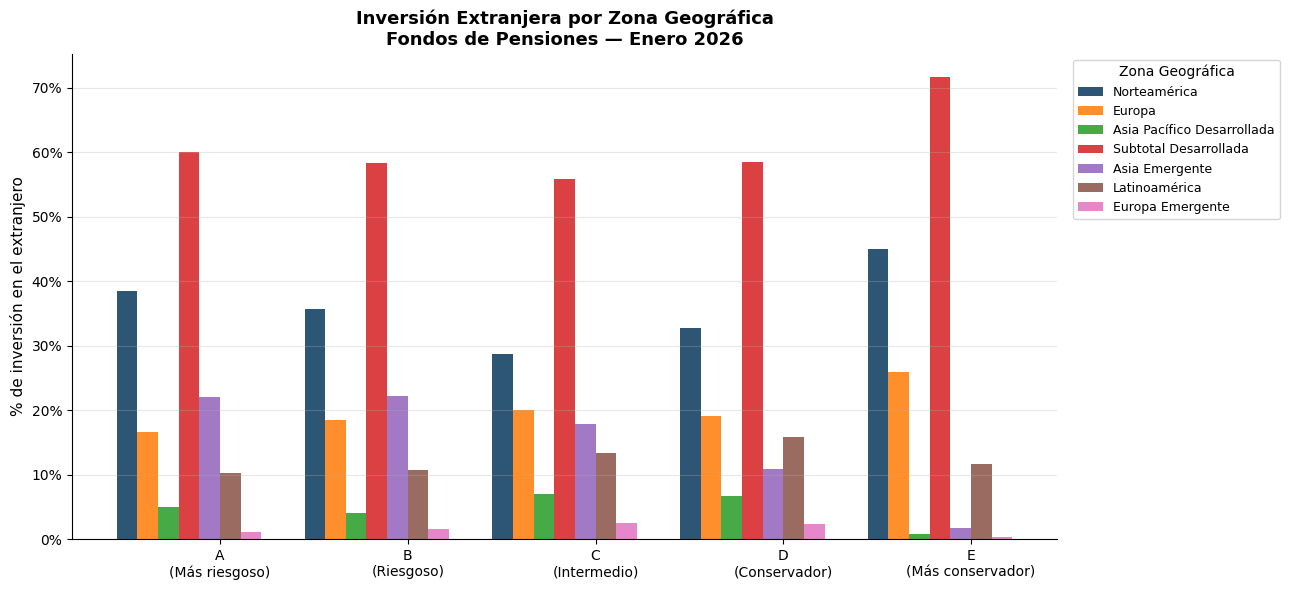

In [35]:
zonas  = df['Zona'].tolist()
valores = df[['A','B','C','D','E']].values
colores = ["#103f61",'#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

x = np.arange(5)
n = len(zonas)
ancho = 0.11
offsets = np.linspace(-(n-1)/2 * ancho, (n-1)/2 * ancho, n)

fig, ax = plt.subplots(figsize=(13, 6))

for i, (zona, color) in enumerate(zip(zonas, colores)):
    ax.bar(x + offsets[i], valores[i], width=ancho, label=zona, color=color, alpha=0.88)

etiquetas = ['A\n(Más riesgoso)', 'B\n(Riesgoso)', 'C\n(Intermedio)', 'D\n(Conservador)', 'E\n(Más conservador)']
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_ylabel('% de inversión en el extranjero', fontsize=11)
ax.set_title('Inversión Extranjera por Zona Geográfica\nFondos de Pensiones — Enero 2026',
             fontsize=13, fontweight='bold')
ax.legend(title='Zona Geográfica', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# **Ejemplo 2** - Construcción de base de datos mediantes múltiples PDFs

El objetivo es lograr extraer las rentabilidad de varios paginas del mismo `PDFs` y ademas de distintos `PDFs`, para luego poder generalizar el proceso a todos los PDFs de la carpeta. 

**Paso 1** — Abrir un solo PDF y ver el texto crudo de las páginas que nos interesan:

In [36]:
with pdfplumber.open(carpeta / 'ene_2026.pdf') as pdf:
    texto_crudo = '\n'.join(pdf.pages[i].extract_text() or '' for i in range(10, 14))

print(texto_crudo[:1500])

3. Rentabilidad nominal de los Fondos de Pensiones16
3.1 Rentabilidad nominal del mes de enero de 2026
La rentabilidad nominal de la cuota de los distintos Tipos de Fondos de Pensiones, durante
el mes de enero de 2026 , para los últimos 12 y 36 meses, alcanzó los siguientes valores:
Tabla N° 10
Rentabilidad Nominal de los Fondos de Pensiones
En porcentaje
Promedio anual últimos
Acumulado Últimos 12 meses
Fondo de Pensiones Enero 2026 36 meses
Ene 2026 – Ene 2026 Feb 2025 – Ene 2026
Feb 2023 – Ene 2026
Tipo A - Más riesgoso 0,99 0,99 16,75 14,87
Tipo B – Riesgoso 0,68 0,68 15,41 13,26
Tipo C – Intermedio 0,43 0,43 14,83 10,45
Tipo D - Conservador 0,36 0,36 13,87 7,80
Tipo E - Más conservador -0,69 -0,69 10,81 6,35
Nota: La rentabilidad es variable, por lo que no se garantiza que rentabilidades pasadas se
repitan en el futuro.
Fuente: Superintendencia de Pensiones a partir de Base de Datos del Sistema de Pensiones
16 Se entiende por rentabilidad nominal de los Fondos de Pensiones en un m

**Paso 2** — Extraer la fecha del PDF:




In [37]:
patron_fecha = re.compile(
    r'(Enero|Febrero|Marzo|Abril|Mayo|Junio|Julio|Agosto|Septiembre|Octubre|Noviembre|Diciembre)\s+de\s+(\d{4})'
)

with pdfplumber.open(carpeta / 'ene_2026.pdf') as pdf:
    texto_portada = pdf.pages[0].extract_text()

m = patron_fecha.search(texto_portada)
fecha = f"{m.group(1)} {m.group(2)}"
print("Fecha detectada:", fecha)

Fecha detectada: Enero 2026


**Paso 3** — Extraer el bloque de datos de un solo fondo (Fondo A):

In [38]:
patron_bloque = re.compile(
    r'Rentabilidad Nominal del Fondo Tipo ([A-E])[^\n]*\n.*?\n.*?\n.*?\n.*?\n'
    r'((?:(?:CAPITAL|CUPRUM|HABITAT|MODELO|PLANVITAL|PROVIDA|UNO)[^\n]+\n)+)',
    re.DOTALL
)

bloques = patron_bloque.findall(texto_crudo)

print(f"Fondos encontrados: {len(bloques)}")
print()
for fondo, bloque in bloques:
    print(f"--- Fondo {fondo} ---")
    print(bloque)

Fondos encontrados: 5

--- Fondo A ---
CAPITAL 1,07 1,07 17,34 14,90
CUPRUM 1,21 1,21 16,89 14,90
HABITAT 0,81 0,81 16,58 14,92
MODELO 0,82 0,82 15,73 14,84
PLANVITAL 0,92 0,92 17,12 14,94
PROVIDA 1,03 1,03 16,52 14,65
UNO 0,94 0,94 16,67 15,02

--- Fondo B ---
CAPITAL 0,77 0,77 16,18 13,37
CUPRUM 0,91 0,91 15,49 13,31
HABITAT 0,56 0,56 15,43 13,29
MODELO 0,47 0,47 14,56 13,26
PLANVITAL 0,66 0,66 15,75 13,43
PROVIDA 0,73 0,73 15,13 12,94
UNO 0,67 0,67 15,43 13,33

--- Fondo C ---
CAPITAL 0,44 0,44 15,29 10,69
CUPRUM 0,62 0,62 14,96 10,58
HABITAT 0,38 0,38 14,99 10,53
MODELO 0,14 0,14 13,86 10,56
PLANVITAL 0,41 0,41 15,27 10,66
PROVIDA 0,41 0,41 14,26 9,92
UNO 0,46 0,46 15,00 10,57

--- Fondo D ---
CAPITAL 0,35 0,35 14,12 7,97
CUPRUM 0,50 0,50 13,99 8,03
HABITAT 0,33 0,33 14,16 7,88
MODELO -0,04 -0,04 12,39 7,73
PLANVITAL 0,29 0,29 14,08 7,98
PROVIDA 0,38 0,38 13,53 7,51
UNO 0,39 0,39 14,04 8,00

--- Fondo E ---
CAPITAL -0,63 -0,63 11,17 6,48
CUPRUM -0,62 -0,62 11,20 6,59
HABITAT -0,71 

**Paso 4** — Extraer las filas de cada AFP dentro de un bloque:




In [39]:
patron_fila = re.compile(
    r'^(CAPITAL|CUPRUM|HABITAT|MODELO|PLANVITAL|PROVIDA|UNO)'
    r'\s+(-?\d+,\d+)'   # rentabilidad del mes
    r'\s+(-?\d+,\d+)'   # acumulado
    r'\s+(-?\d+,\d+)'   # últimos 12 meses
    r'\s+(-?\d+,\d+)',  # promedio últimos 36 meses
    re.MULTILINE
)

# Probamos con el primer bloque (Fondo A)
fondo, bloque = bloques[0]
filas = patron_fila.findall(bloque)

print(f"Fondo {fondo} — AFPs encontradas: {len(filas)}")
print()
for fila in filas:
    print(fila)

Fondo A — AFPs encontradas: 7

('CAPITAL', '1,07', '1,07', '17,34', '14,90')
('CUPRUM', '1,21', '1,21', '16,89', '14,90')
('HABITAT', '0,81', '0,81', '16,58', '14,92')
('MODELO', '0,82', '0,82', '15,73', '14,84')
('PLANVITAL', '0,92', '0,92', '17,12', '14,94')
('PROVIDA', '1,03', '1,03', '16,52', '14,65')
('UNO', '0,94', '0,94', '16,67', '15,02')


**Paso 5** — Convertir a DataFrame para un solo PDF:

In [50]:
registros = []

for fondo, bloque in bloques:
    for afp, mes, acum, u12m, p36m in patron_fila.findall(bloque):
        registros.append({
            'fecha'    : fecha,
            'fondo'    : fondo,
            'afp'      : afp,
            'rent_mes' : float(mes.replace(',','.')),
            'rent_acum': float(acum.replace(',','.')),
            'rent_12m' : float(u12m.replace(',','.')),
            'rent_36m' : float(p36m.replace(',','.'))
        })

df_ene = pd.DataFrame(registros)
print(df_ene.shape)
print()
print(df_ene.to_string(index=False))

(35, 7)

    fecha fondo       afp  rent_mes  rent_acum  rent_12m  rent_36m
Mayo 2026     A   CAPITAL      1.07       1.07     17.34     14.90
Mayo 2026     A    CUPRUM      1.21       1.21     16.89     14.90
Mayo 2026     A   HABITAT      0.81       0.81     16.58     14.92
Mayo 2026     A    MODELO      0.82       0.82     15.73     14.84
Mayo 2026     A PLANVITAL      0.92       0.92     17.12     14.94
Mayo 2026     A   PROVIDA      1.03       1.03     16.52     14.65
Mayo 2026     A       UNO      0.94       0.94     16.67     15.02
Mayo 2026     B   CAPITAL      0.77       0.77     16.18     13.37
Mayo 2026     B    CUPRUM      0.91       0.91     15.49     13.31
Mayo 2026     B   HABITAT      0.56       0.56     15.43     13.29
Mayo 2026     B    MODELO      0.47       0.47     14.56     13.26
Mayo 2026     B PLANVITAL      0.66       0.66     15.75     13.43
Mayo 2026     B   PROVIDA      0.73       0.73     15.13     12.94
Mayo 2026     B       UNO      0.67       0.67     15

**Paso 6** — Repetir para todos los PDFs y armar el dataset completo:

In [ ]:
registros_total = []

for pdf_path in archivos:
    with pdfplumber.open(pdf_path) as pdf:
        # Fecha desde portada
        texto_portada = pdf.pages[0].extract_text()
        m = patron_fecha.search(texto_portada)
        fecha = f"{m.group(1)} {m.group(2)}"

        # Texto páginas con rentabilidades
        texto = '\n'.join(pdf.pages[i].extract_text() or '' for i in range(10, 14))

    # Extraer bloques y filas
    for fondo, bloque in patron_bloque.findall(texto):
        for afp, mes, acum, u12m, p36m in patron_fila.findall(bloque):
            registros_total.append({
                'fecha'    : fecha,
                'fondo'    : fondo,
                'afp'      : afp,
                'rent_mes' : float(mes.replace(',','.')),
                'rent_acum': float(acum.replace(',','.')),
                'rent_12m' : float(u12m.replace(',','.')),
                'rent_36m' : float(p36m.replace(',','.'))
            })

df = pd.DataFrame(registros_total)
print(df.shape)  # debe ser 175 filas (5 PDFs × 5 fondos × 7 AFPs)
df

(175, 7)


,fecha,fondo,afp,rent_mes,rent_acum,rent_12m,rent_36m
0,Abril 2026,A,CAPITAL,5.63,6.12,25.15,18.47
1,Abril 2026,A,CUPRUM,5.69,6.19,24.85,18.48
2,Abril 2026,A,HABITAT,5.36,5.64,24.32,18.38
3,Abril 2026,A,MODELO,5.59,5.94,24.43,18.41
4,Abril 2026,A,PLANVITAL,5.60,5.88,24.82,18.44
...,...,...,...,...,...,...,...
170,Mayo 2026,E,HABITAT,-1.20,-0.77,6.15,6.51
171,Mayo 2026,E,MODELO,-1.79,-1.54,5.61,5.94
172,Mayo 2026,E,PLANVITAL,-1.30,-0.71,6.42,6.46
173,Mayo 2026,E,PROVIDA,-1.33,-0.92,5.99,6.24


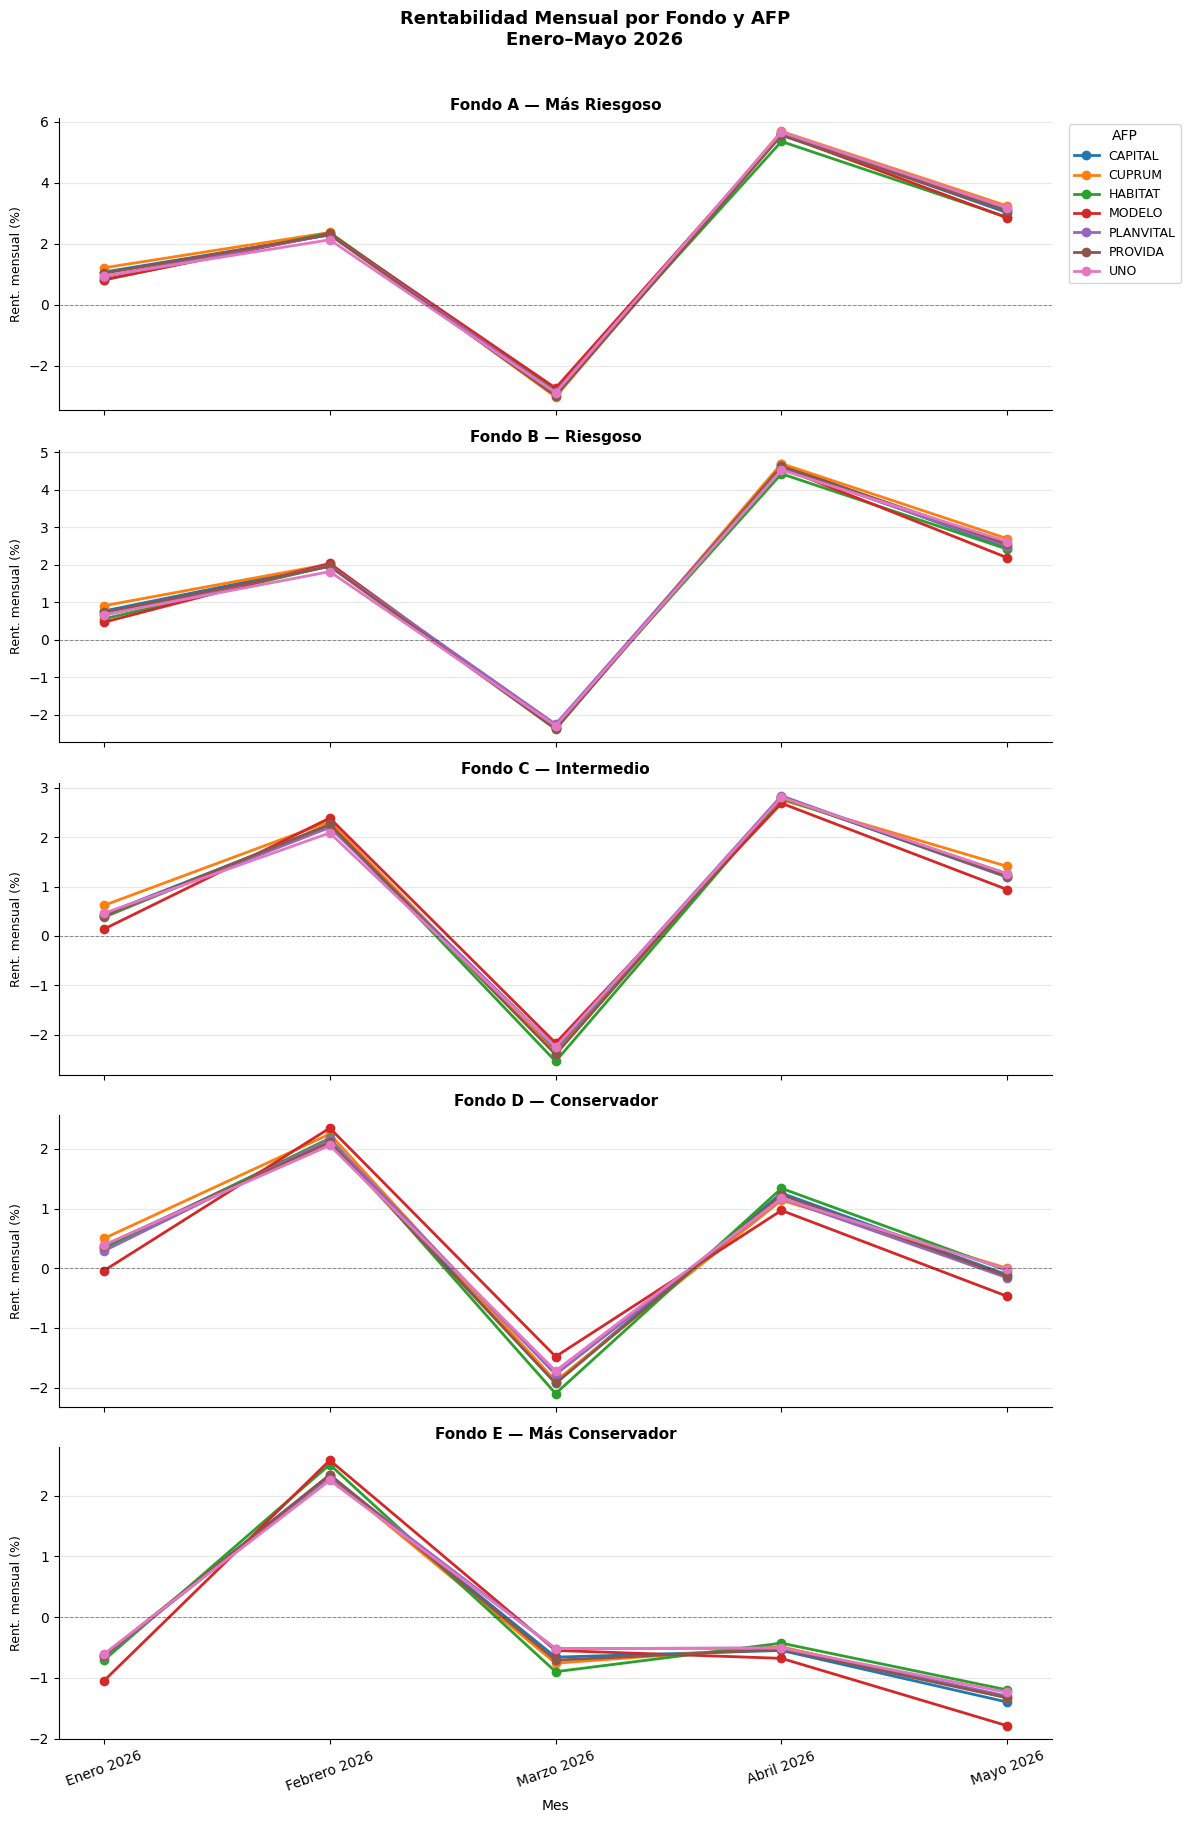

In [51]:
fondos = ['A', 'B', 'C', 'D', 'E']
nombres_fondo = {
    'A': 'Fondo A — Más Riesgoso',
    'B': 'Fondo B — Riesgoso',
    'C': 'Fondo C — Intermedio',
    'D': 'Fondo D — Conservador',
    'E': 'Fondo E — Más Conservador'
}
afps    = df['afp'].unique()
colores = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

# Orden cronológico de fechas
orden_fechas = ['Enero 2026', 'Febrero 2026', 'Marzo 2026', 'Abril 2026', 'Mayo 2026']

fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)

for ax, fondo in zip(axes, fondos):
    df_f = df[df['fondo'] == fondo].copy()

    for afp, color in zip(afps, colores):
        df_afp = (
            df_f[df_f['afp'] == afp]
            .set_index('fecha')
            .reindex(orden_fechas)
        )
        ax.plot(orden_fechas, df_afp['rent_mes'], marker='o',
                label=afp, color=color, linewidth=2)

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_title(nombres_fondo[fondo], fontsize=11, fontweight='bold')
    ax.set_ylabel('Rent. mensual (%)', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(title='AFP', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[-1].set_xlabel('Mes', fontsize=10)
plt.xticks(rotation=20)
plt.suptitle('Rentabilidad Mensual por Fondo y AFP\nEnero–Mayo 2026',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# **Ejemplo 3** - Construcción de base de datos pero con extracción puntual 

**Paso 1** — Extraer el texto de la página:

In [55]:



with pdfplumber.open(carpeta / 'ene_2026.pdf') as pdf:
    texto_p16 = pdf.pages[15].extract_text()

print(texto_p16)

5. Distribución sectorial de las inversiones en acciones nacionales
Al 31 de enero de 2026 el Sistema de Fondos de Pensiones mantenía inversiones en
acciones de sociedades anónimas nacionales por un monto de $23.771.399 millones,
equivalente a 10,8% del valor total de los activos del Sistema. La inversión en este tipo de
instrumentos al 31 de enero de 2025 alcanzaba a $13.165.153 millones, registrándose un
aumento nominal de 80,6% (74,6% real) en los últimos doce meses. En los cuadros
siguientes se presenta la inversión por Tipo de Fondo de Pensiones, el porcentaje que
representan estos instrumentos respecto del total de activos de cada Tipo de Fondo y la
evolución de la inversión en acciones por sector económico.
Tabla N° 17
Inversión en Acciones Nacionales
En millones de pesos, al 31 de enero de 2026
% Valor Total
A B C D E
SECTOR ECONÓMICO Total Sistema Fondos de
Más Riesgoso Riesgoso Intermedio Conservador Más conservador
Pensiones
ELÉCTRICO 316.500 396.650 661.903 128.466 19.272 1

**Paso 2** — Probar el patrón en una sola línea:

In [57]:
linea = "ELÉCTRICO 316.500 396.650 661.903 128.466 19.272 1.522.791 0,7%"

patron_num = r'(\d+[.\d]*)'
patron_pct = r'(\d+,\d+%)'

print("Números:", re.findall(patron_num, linea))
print("Porcentaje:", re.findall(patron_pct, linea))


Números: ['316.500', '396.650', '661.903', '128.466', '19.272', '1.522.791', '0', '7']
Porcentaje: ['0,7%']


In [66]:
patron_sector_montos = re.compile(
    r'^(ELÉCTRICO|TELECOMUNICACIONES|SERVICIOS|INDUSTRIAL|RECURSOS NATURALES|TOTAL SISTEMA)'
    r'\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)',
    re.MULTILINE
)

registros_sector = []

for pdf_path in archivos:
    with pdfplumber.open(pdf_path) as pdf:
        texto_portada = pdf.pages[0].extract_text()
        m_fecha = patron_fecha.search(texto_portada)
        fecha = f"{m_fecha.group(1)} {m_fecha.group(2)}"
        texto = pdf.pages[15].extract_text()

    filas = patron_sector_montos.findall(texto)

    # Extraer totales por fondo (última fila = TOTAL SISTEMA)
    total = [f for f in filas if f[0] == 'TOTAL SISTEMA'][0]
    totales = {fondo: int(total[i+1].replace('.','')) for i, fondo in enumerate(['A','B','C','D','E'])}

    for fila in filas:
        if fila[0] == 'TOTAL SISTEMA':
            continue
        sector = fila[0]
        for i, fondo in enumerate(['A','B','C','D','E']):
            monto = int(fila[i+1].replace('.',''))
            pct   = round(monto / totales[fondo] * 100, 1)
            registros_sector.append({
                'fecha'  : fecha,
                'sector' : sector,
                'fondo'  : fondo,
                'monto'  : monto,
                'pct'    : pct
            })

df_long = pd.DataFrame(registros_sector)
print(df_long.shape)  # 125 filas (5 PDFs × 5 sectores × 5 fondos)
print()
print(df_long.to_string(index=False))

(125, 5)

       fecha             sector fondo   monto  pct
  Abril 2026          ELÉCTRICO     A  313829  5.4
  Abril 2026          ELÉCTRICO     B  400938  6.5
  Abril 2026          ELÉCTRICO     C  641625  8.6
  Abril 2026          ELÉCTRICO     D  133992  5.9
  Abril 2026          ELÉCTRICO     E   15444  3.4
  Abril 2026 TELECOMUNICACIONES     A   10810  0.2
  Abril 2026 TELECOMUNICACIONES     B   29803  0.5
  Abril 2026 TELECOMUNICACIONES     C   53390  0.7
  Abril 2026 TELECOMUNICACIONES     D   16627  0.7
  Abril 2026 TELECOMUNICACIONES     E    1385  0.3
  Abril 2026          SERVICIOS     A 3993666 68.1
  Abril 2026          SERVICIOS     B 4313163 70.1
  Abril 2026          SERVICIOS     C 4736650 63.4
  Abril 2026          SERVICIOS     D 1472670 64.4
  Abril 2026          SERVICIOS     E  307779 67.8
  Abril 2026         INDUSTRIAL     A  345527  5.9
  Abril 2026         INDUSTRIAL     B  299075  4.9
  Abril 2026         INDUSTRIAL     C  448148  6.0
  Abril 2026         

In [76]:
df_wide = df_long.pivot_table(
    index   = ['fecha', 'sector'],
    columns = 'fondo',
    values  = 'porcentaje'
).reset_index()

df_wide.columns.name = None
df_wide.columns = ['fecha', 'sector', 'fondo_A', 'fondo_B', 'fondo_C', 'fondo_D', 'fondo_E']

print(df_wide.shape)  # 25 filas (5 PDFs × 5 sectores)
print()
print(df_wide.to_string(index=False))

(25, 7)

       fecha             sector  fondo_A  fondo_B  fondo_C  fondo_D  fondo_E
  Abril 2026          ELÉCTRICO     14.4     11.8     10.2      6.2      1.9
  Abril 2026         INDUSTRIAL     14.4     11.8     10.2      6.2      1.9
  Abril 2026 RECURSOS NATURALES     14.4     11.8     10.2      6.2      1.9
  Abril 2026          SERVICIOS     14.4     11.8     10.2      6.2      1.9
  Abril 2026 TELECOMUNICACIONES     14.4     11.8     10.2      6.2      1.9
  Enero 2026          ELÉCTRICO     16.1     13.3     11.2      6.6      2.3
  Enero 2026         INDUSTRIAL     16.1     13.3     11.2      6.6      2.3
  Enero 2026 RECURSOS NATURALES     16.1     13.3     11.2      6.6      2.3
  Enero 2026          SERVICIOS     16.1     13.3     11.2      6.6      2.3
  Enero 2026 TELECOMUNICACIONES     16.1     13.3     11.2      6.6      2.3
Febrero 2026          ELÉCTRICO     15.2     12.6     10.6      6.3      2.1
Febrero 2026         INDUSTRIAL     15.2     12.6     10.6      6.3

**Paso 8** — Graficar la evolución de los porcentajes de inversión internacional por AFP

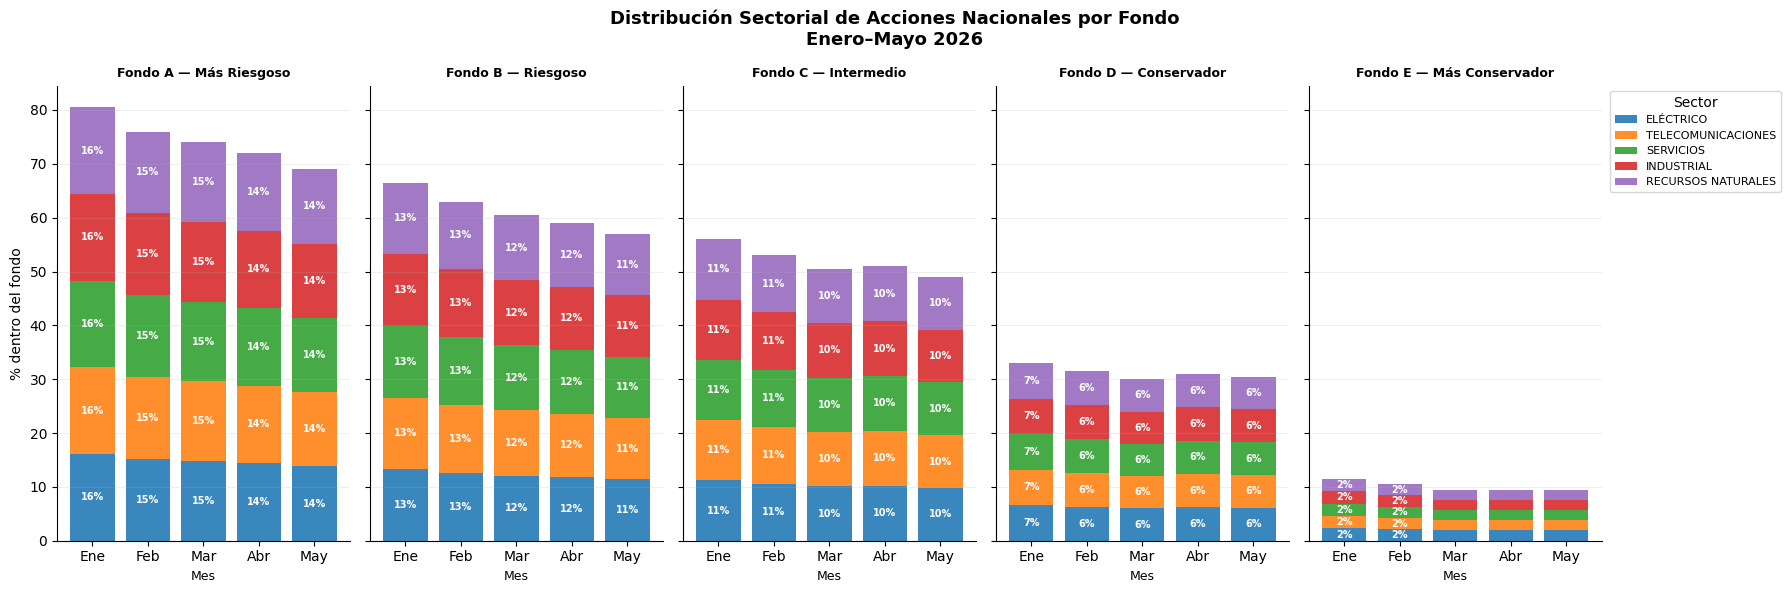

In [74]:
orden_fechas  = ['Enero 2026', 'Febrero 2026', 'Marzo 2026', 'Abril 2026', 'Mayo 2026']
etiq_fechas   = ['Ene', 'Feb', 'Mar', 'Abr', 'May']
fondos        = ['A', 'B', 'C', 'D', 'E']
nombres_fondo = {
    'A': 'Fondo A — Más Riesgoso',
    'B': 'Fondo B — Riesgoso',
    'C': 'Fondo C — Intermedio',
    'D': 'Fondo D — Conservador',
    'E': 'Fondo E — Más Conservador'
}
sectores = ['ELÉCTRICO','TELECOMUNICACIONES','SERVICIOS','INDUSTRIAL','RECURSOS NATURALES']
colores  = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

for ax, fondo in zip(axes, fondos):
    df_f = df_long[df_long['fondo'] == fondo]
    bottom = [0] * len(orden_fechas)

    for sector, color in zip(sectores, colores):
        valores = (
            df_f[df_f['sector'] == sector]
            .set_index('fecha')
            .reindex(orden_fechas)['porcentaje']
            .fillna(0)
            .values
        )
        ax.bar(etiq_fechas, valores, bottom=bottom,
               label=sector, color=color, alpha=0.88)

        # Etiqueta dentro de la barra si el valor es visible
        for j, (v, b) in enumerate(zip(valores, bottom)):
            if v > 2:
                ax.text(j, b + v/2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=7, color='white', fontweight='bold')

        bottom = [b + v for b, v in zip(bottom, valores)]

    ax.set_title(nombres_fondo[fondo], fontsize=9, fontweight='bold')
    ax.set_xlabel('Mes', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('% dentro del fondo', fontsize=10)
axes[-1].legend(title='Sector', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Distribución Sectorial de Acciones Nacionales por Fondo\nEnero–Mayo 2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()